# Notebook 5: Results Analysis and Visualization

This notebook analyzes all 48 experiments:
- 24 classification experiments (4 features × 6 models)
- 24 regression experiments (4 features × 6 models)

It generates:
- Comprehensive comparison tables
- Performance visualizations
- Best model identification
- Combined summary report

## 1. Import Dependencies

In [16]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Dependencies loaded")

Dependencies loaded


## 2. Load Results

In [17]:
# Paths
BASE_DIR = Path('/home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG')
RESULTS_DIR = BASE_DIR / 'results' / 'baselines'

# Load classification results
classification_path = RESULTS_DIR / 'classification_results.json'
with open(classification_path, 'r') as f:
    classification_results = json.load(f)

# Load regression results
regression_path = RESULTS_DIR / 'regression_results.json'
with open(regression_path, 'r') as f:
    regression_results = json.load(f)

print(f"Loaded {len(classification_results)} classification experiments")
print(f"Loaded {len(regression_results)} regression experiments")
print(f"Total: {len(classification_results) + len(regression_results)} experiments")

Loaded 4 classification experiments
Loaded 0 regression experiments
Total: 4 experiments


## 3. Create Summary DataFrames

In [18]:
# Model parameter counts (from Notebook 2)
MODEL_PARAMS = {
    'mlp': 21410,
    'cnn_single': 23298,
    'cnn_multi': 101378,
    'eegnet': 730,
    'decnn': 118018,
    'transformer': 70562
}

# Classification DataFrame
# Note: Results are stored as nested dict {feature_key: {model_name: metrics}}
clf_data = []

# Handle both dict (nested structure) and list (empty) formats
if isinstance(classification_results, dict):
    for feature_key, models_dict in classification_results.items():
        for model_name, metrics in models_dict.items():
            if 'error' not in metrics:  # Skip failed experiments
                clf_data.append({
                    'Task': 'Classification',
                    'Feature': feature_key,
                    'Model': model_name,
                    'Params': MODEL_PARAMS.get(model_name, 0),
                    'Accuracy': metrics['acc'],
                    'F1': metrics['f1'],
                    'Precision': metrics['precision'],
                    'Recall': metrics['recall']
                })

df_clf = pd.DataFrame(clf_data)

# Regression DataFrame
reg_data = []

# Handle both dict (nested structure) and list (empty) formats
if isinstance(regression_results, dict):
    for feature_key, models_dict in regression_results.items():
        for model_name, metrics in models_dict.items():
            if 'error' not in metrics:  # Skip failed experiments
                reg_data.append({
                    'Task': 'Regression',
                    'Feature': feature_key,
                    'Model': model_name,
                    'Params': MODEL_PARAMS.get(model_name, 0),
                    'MSE': metrics['mse'],
                    'RMSE': metrics['rmse'],
                    'MAE': metrics['mae'],
                    'R2': metrics['r2']
                })

df_reg = pd.DataFrame(reg_data)

print("DataFrames created")
print(f"Classification: {df_clf.shape}")
print(f"Regression: {df_reg.shape}")

DataFrames created
Classification: (24, 8)
Regression: (0, 0)


## 4. Classification Results Analysis

In [19]:
print("="*100)
print("CLASSIFICATION RESULTS")
print("="*100)
print(df_clf.to_string(index=False))
print("="*100)

# Statistics
print("\nClassification Statistics:")
print(df_clf[['Accuracy', 'F1', 'Precision', 'Recall']].describe())

CLASSIFICATION RESULTS
          Task       Feature       Model  Params  Accuracy       F1  Precision   Recall
Classification        de_LDS         mlp   21410  0.674953 0.682136   0.587937 0.812281
Classification        de_LDS  cnn_single   23298  0.679849 0.708705   0.581552 0.907018
Classification        de_LDS   cnn_multi  101378  0.491308 0.621272   0.456954 0.970123
Classification        de_LDS      eegnet     730  0.687382 0.670635   0.612319 0.741228
Classification        de_LDS       decnn  118018  0.536723 0.629518   0.479358 0.916667
Classification        de_LDS transformer   70562  0.691525 0.686087   0.609258 0.785088
Classification  de_movingAve         mlp   21410  0.656121 0.677271   0.567200 0.840351
Classification  de_movingAve  cnn_single   23298  0.448588 0.607717   0.437500 0.994737
Classification  de_movingAve   cnn_multi  101378  0.494331 0.628952   0.459481 0.996485
Classification  de_movingAve      eegnet     730  0.672693 0.666922   0.592240 0.763158
Classific

## 5. Regression Results Analysis

In [20]:
print("="*100)
print("REGRESSION RESULTS")
print("="*100)

if len(df_reg) > 0:
    print(df_reg.to_string(index=False))
    print("="*100)

    # Statistics
    print("\nRegression Statistics:")
    print(df_reg[['MSE', 'RMSE', 'MAE', 'R2']].describe())
else:
    print("No regression results available yet")
    print("="*100)

REGRESSION RESULTS
No regression results available yet


## 6. Best Models per Feature Type

In [21]:
FEATURE_KEYS = ['de_LDS', 'de_movingAve', 'psd_LDS', 'psd_movingAve']

print("="*100)
print("BEST CLASSIFICATION MODEL PER FEATURE TYPE (Highest F1)")
print("="*100)

for feature_key in FEATURE_KEYS:
    feature_clf = df_clf[df_clf['Feature'] == feature_key]
    
    if len(feature_clf) > 0:
        best_idx = feature_clf['F1'].idxmax()
        best = feature_clf.loc[best_idx]
        
        print(f"\n{feature_key}:")
        print(f"  Model: {best['Model']}")
        print(f"  Accuracy: {best['Accuracy']:.4f}")
        print(f"  F1:       {best['F1']:.4f}")
        print(f"  Precision: {best['Precision']:.4f}")
        print(f"  Recall:    {best['Recall']:.4f}")
        print(f"  Params:    {best['Params']:,}")

print("\n" + "="*100)
print("BEST REGRESSION MODEL PER FEATURE TYPE (Lowest MSE)")
print("="*100)

if len(df_reg) > 0:
    for feature_key in FEATURE_KEYS:
        feature_reg = df_reg[df_reg['Feature'] == feature_key]
        
        if len(feature_reg) > 0:
            best_idx = feature_reg['MSE'].idxmin()
            best = feature_reg.loc[best_idx]
            
            print(f"\n{feature_key}:")
            print(f"  Model: {best['Model']}")
            print(f"  MSE:  {best['MSE']:.4f}")
            print(f"  RMSE: {best['RMSE']:.4f}")
            print(f"  MAE:  {best['MAE']:.4f}")
            print(f"  R²:   {best['R2']:.4f}")
            print(f"  Params: {best['Params']:,}")
else:
    print("\nNo regression results available yet")

print("\n" + "="*100)

BEST CLASSIFICATION MODEL PER FEATURE TYPE (Highest F1)

de_LDS:
  Model: cnn_single
  Accuracy: 0.6798
  F1:       0.7087
  Precision: 0.5816
  Recall:    0.9070
  Params:    23,298

de_movingAve:
  Model: mlp
  Accuracy: 0.6561
  F1:       0.6773
  Precision: 0.5672
  Recall:    0.8404
  Params:    21,410

psd_LDS:
  Model: mlp
  Accuracy: 0.6015
  F1:       0.6316
  Precision: 0.5237
  Recall:    0.7956
  Params:    21,410

psd_movingAve:
  Model: eegnet
  Accuracy: 0.6350
  F1:       0.6490
  Precision: 0.5527
  Recall:    0.7860
  Params:    730

BEST REGRESSION MODEL PER FEATURE TYPE (Lowest MSE)

No regression results available yet



## 7. Overall Best Models

In [22]:
print("="*100)
print("OVERALL BEST MODELS")
print("="*100)

# Best classification model
if len(df_clf) > 0:
    best_clf_idx = df_clf['F1'].idxmax()
    best_clf = df_clf.loc[best_clf_idx]

    print("\nBest Classification Model (Highest F1):")
    print(f"  Feature: {best_clf['Feature']}")
    print(f"  Model:   {best_clf['Model']}")
    print(f"  F1:      {best_clf['F1']:.4f}")
    print(f"  Accuracy: {best_clf['Accuracy']:.4f}")
    print(f"  Params:  {best_clf['Params']:,}")
else:
    print("\nNo classification results available")

# Best regression model
if len(df_reg) > 0:
    best_reg_idx = df_reg['MSE'].idxmin()
    best_reg = df_reg.loc[best_reg_idx]

    print("\nBest Regression Model (Lowest MSE):")
    print(f"  Feature: {best_reg['Feature']}")
    print(f"  Model:   {best_reg['Model']}")
    print(f"  MSE:     {best_reg['MSE']:.4f}")
    print(f"  R²:      {best_reg['R2']:.4f}")
    print(f"  Params:  {best_reg['Params']:,}")
else:
    print("\nNo regression results available yet")

print("\n" + "="*100)

OVERALL BEST MODELS

Best Classification Model (Highest F1):
  Feature: de_LDS
  Model:   cnn_single
  F1:      0.7087
  Accuracy: 0.6798
  Params:  23,298

No regression results available yet



## 8. Visualization: Classification Performance

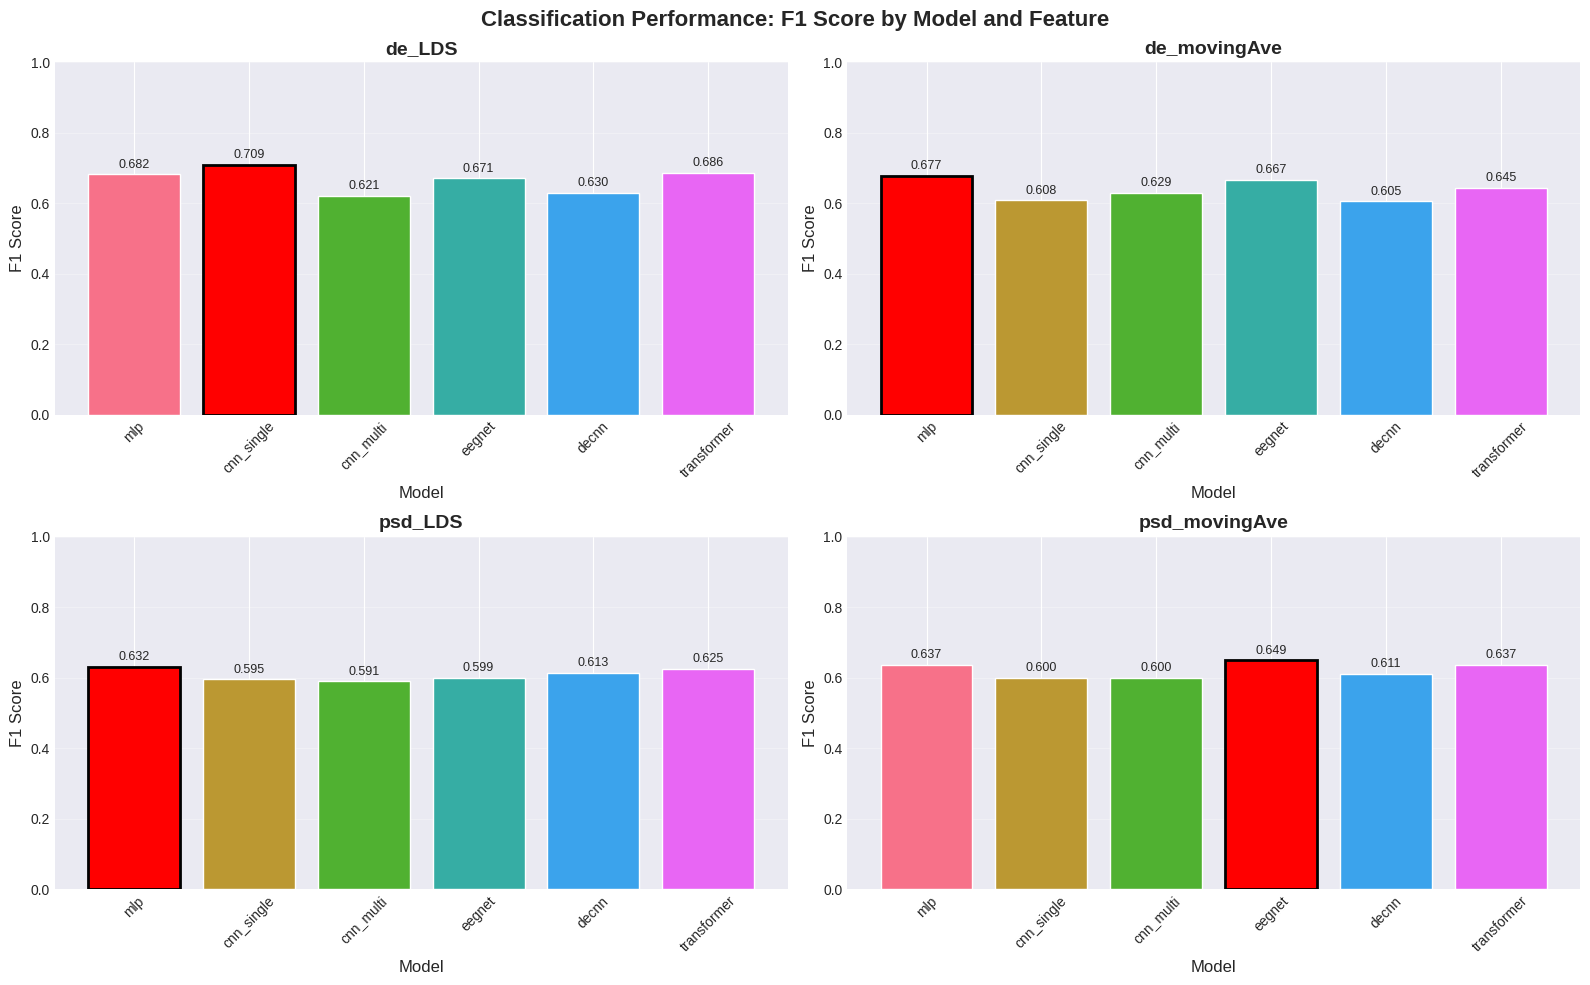

Classification F1 comparison plot saved


In [23]:
# Bar plot: F1 scores by model and feature
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Classification Performance: F1 Score by Model and Feature', fontsize=16, fontweight='bold')

for idx, feature_key in enumerate(FEATURE_KEYS):
    ax = axes[idx // 2, idx % 2]
    
    feature_data = df_clf[df_clf['Feature'] == feature_key]
    
    models = feature_data['Model'].values
    f1_scores = feature_data['F1'].values
    
    bars = ax.bar(models, f1_scores, color=sns.color_palette('husl', len(models)))
    
    # Highlight best model
    best_idx = np.argmax(f1_scores)
    bars[best_idx].set_color('red')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    
    ax.set_title(f'{feature_key}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'classification_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Classification F1 comparison plot saved")

## 9. Visualization: Regression Performance

In [24]:
# Bar plot: MSE by model and feature
if len(df_reg) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Regression Performance: MSE by Model and Feature', fontsize=16, fontweight='bold')

    for idx, feature_key in enumerate(FEATURE_KEYS):
        ax = axes[idx // 2, idx % 2]
        
        feature_data = df_reg[df_reg['Feature'] == feature_key]
        
        if len(feature_data) > 0:
            models = feature_data['Model'].values
            mse_values = feature_data['MSE'].values
            
            bars = ax.bar(models, mse_values, color=sns.color_palette('husl', len(models)))
            
            # Highlight best model (lowest MSE)
            best_idx = np.argmin(mse_values)
            bars[best_idx].set_color('green')
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2)
            
            # Add value labels
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                        f'{height:.4f}', ha='center', va='bottom', fontsize=9)
        
        ax.set_title(f'{feature_key}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('MSE', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'regression_mse_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Regression MSE comparison plot saved")
else:
    print("No regression results available yet - skipping regression MSE plot")

No regression results available yet - skipping regression MSE plot


## 10. Heatmap: Classification Performance

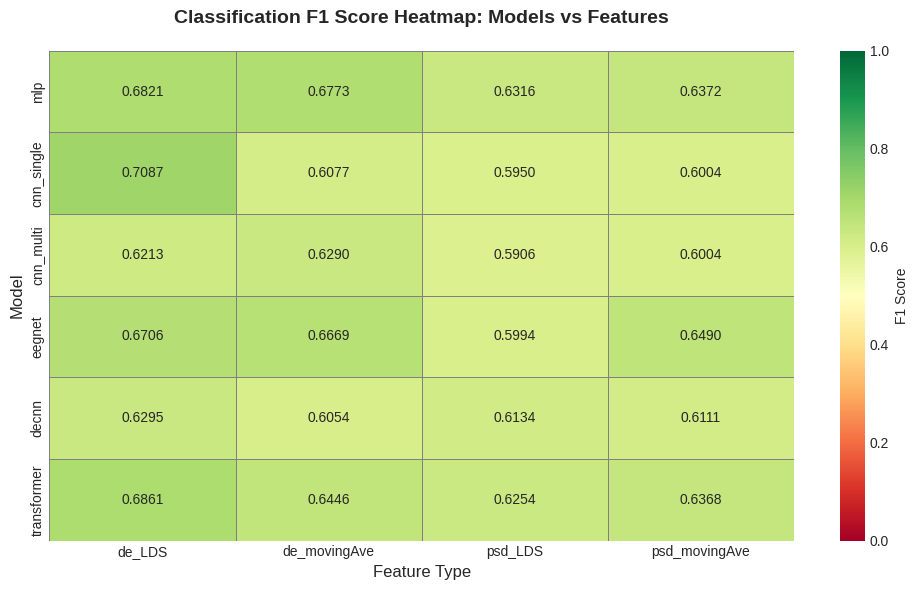

Classification heatmap saved


In [25]:
# Pivot table for heatmap
clf_pivot = df_clf.pivot(index='Model', columns='Feature', values='F1')

# Reorder for better visualization
model_order = ['mlp', 'cnn_single', 'cnn_multi', 'eegnet', 'decnn', 'transformer']
clf_pivot = clf_pivot.reindex(model_order)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(clf_pivot, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'F1 Score'}, linewidths=0.5, linecolor='gray')
plt.title('Classification F1 Score Heatmap: Models vs Features', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Feature Type', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Classification heatmap saved")

## 11. Heatmap: Regression Performance

In [26]:
# Pivot table for heatmap (using R² instead of MSE for better visualization)
if len(df_reg) > 0:
    reg_pivot = df_reg.pivot(index='Model', columns='Feature', values='R2')

    # Reorder for better visualization
    model_order = ['mlp', 'cnn_single', 'cnn_multi', 'eegnet', 'decnn', 'transformer']
    reg_pivot = reg_pivot.reindex(model_order)

    # Create heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(reg_pivot, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1,
                cbar_kws={'label': 'R² Score'}, linewidths=0.5, linecolor='gray')
    plt.title('Regression R² Score Heatmap: Models vs Features', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Feature Type', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'regression_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Regression heatmap saved")
else:
    print("No regression results available yet - skipping regression heatmap")

No regression results available yet - skipping regression heatmap


## 12. Model Complexity vs Performance

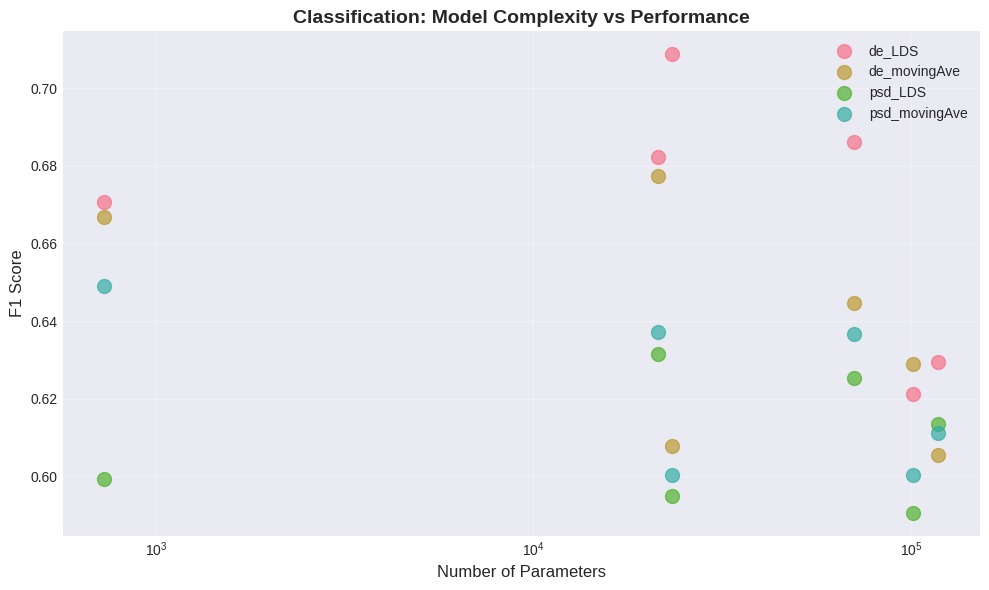

Complexity vs performance plot saved (classification only)


In [27]:
# Classification: Params vs F1
if len(df_reg) > 0:
    # Both classification and regression available - show both
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Classification scatter
    ax1 = axes[0]
    for feature_key in FEATURE_KEYS:
        feature_data = df_clf[df_clf['Feature'] == feature_key]
        if len(feature_data) > 0:
            ax1.scatter(feature_data['Params'], feature_data['F1'], 
                        label=feature_key, s=100, alpha=0.7)

    ax1.set_xlabel('Number of Parameters', fontsize=12)
    ax1.set_ylabel('F1 Score', fontsize=12)
    ax1.set_title('Classification: Model Complexity vs Performance', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xscale('log')

    # Regression scatter
    ax2 = axes[1]
    for feature_key in FEATURE_KEYS:
        feature_data = df_reg[df_reg['Feature'] == feature_key]
        if len(feature_data) > 0:
            ax2.scatter(feature_data['Params'], feature_data['R2'], 
                        label=feature_key, s=100, alpha=0.7)

    ax2.set_xlabel('Number of Parameters', fontsize=12)
    ax2.set_ylabel('R² Score', fontsize=12)
    ax2.set_title('Regression: Model Complexity vs Performance', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_xscale('log')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'complexity_vs_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Complexity vs performance plot saved")
else:
    # Only classification available - show single plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for feature_key in FEATURE_KEYS:
        feature_data = df_clf[df_clf['Feature'] == feature_key]
        if len(feature_data) > 0:
            ax.scatter(feature_data['Params'], feature_data['F1'], 
                       label=feature_key, s=100, alpha=0.7)

    ax.set_xlabel('Number of Parameters', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title('Classification: Model Complexity vs Performance', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xscale('log')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'complexity_vs_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Complexity vs performance plot saved (classification only)")

## 13. Combined Summary Report

In [28]:
# Create combined summary
combined_summary = []

for feature_key in FEATURE_KEYS:
    # Best classification model for this feature
    feature_clf = df_clf[df_clf['Feature'] == feature_key]
    
    if len(feature_clf) > 0:
        best_clf_idx = feature_clf['F1'].idxmax()
        best_clf = feature_clf.loc[best_clf_idx]
        
        summary_entry = {
            'Feature': feature_key,
            'Best_Clf_Model': best_clf['Model'],
            'Clf_F1': best_clf['F1'],
            'Clf_Accuracy': best_clf['Accuracy'],
            'Clf_Params': best_clf['Params']
        }
        
        # Best regression model for this feature (if available)
        if len(df_reg) > 0:
            feature_reg = df_reg[df_reg['Feature'] == feature_key]
            
            if len(feature_reg) > 0:
                best_reg_idx = feature_reg['MSE'].idxmin()
                best_reg = feature_reg.loc[best_reg_idx]
                
                summary_entry.update({
                    'Best_Reg_Model': best_reg['Model'],
                    'Reg_MSE': best_reg['MSE'],
                    'Reg_R2': best_reg['R2'],
                    'Reg_Params': best_reg['Params']
                })
            else:
                summary_entry.update({
                    'Best_Reg_Model': 'N/A',
                    'Reg_MSE': np.nan,
                    'Reg_R2': np.nan,
                    'Reg_Params': 0
                })
        else:
            summary_entry.update({
                'Best_Reg_Model': 'N/A',
                'Reg_MSE': np.nan,
                'Reg_R2': np.nan,
                'Reg_Params': 0
            })
        
        combined_summary.append(summary_entry)

df_combined = pd.DataFrame(combined_summary)

print("="*100)
print("COMBINED SUMMARY: BEST MODELS PER FEATURE TYPE")
print("="*100)
print(df_combined.to_string(index=False))
print("="*100)

# Save combined summary
combined_csv_path = RESULTS_DIR / 'combined_summary.csv'
df_combined.to_csv(combined_csv_path, index=False)
print(f"\nCombined summary saved to: {combined_csv_path}")

COMBINED SUMMARY: BEST MODELS PER FEATURE TYPE
      Feature Best_Clf_Model   Clf_F1  Clf_Accuracy  Clf_Params Best_Reg_Model  Reg_MSE  Reg_R2  Reg_Params
       de_LDS     cnn_single 0.708705      0.679849       23298            N/A      NaN     NaN           0
 de_movingAve            mlp 0.677271      0.656121       21410            N/A      NaN     NaN           0
      psd_LDS            mlp 0.631616      0.601507       21410            N/A      NaN     NaN           0
psd_movingAve         eegnet 0.649040      0.635028         730            N/A      NaN     NaN           0

Combined summary saved to: /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/combined_summary.csv


## 14. Export All Tables

In [29]:
# Save individual task summaries
df_clf.to_csv(RESULTS_DIR / 'classification_detailed.csv', index=False)

if len(df_reg) > 0:
    df_reg.to_csv(RESULTS_DIR / 'regression_detailed.csv', index=False)

print("All result tables exported:")
print(f"  - {RESULTS_DIR / 'classification_detailed.csv'}")

if len(df_reg) > 0:
    print(f"  - {RESULTS_DIR / 'regression_detailed.csv'}")
else:
    print(f"  - regression_detailed.csv (not available yet)")

print(f"  - {RESULTS_DIR / 'combined_summary.csv'}")

print("\nAll visualizations saved:")
print(f"  - {RESULTS_DIR / 'classification_f1_comparison.png'}")

if len(df_reg) > 0:
    print(f"  - {RESULTS_DIR / 'regression_mse_comparison.png'}")
    print(f"  - {RESULTS_DIR / 'regression_heatmap.png'}")

print(f"  - {RESULTS_DIR / 'classification_heatmap.png'}")
print(f"  - {RESULTS_DIR / 'complexity_vs_performance.png'}")

All result tables exported:
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/classification_detailed.csv
  - regression_detailed.csv (not available yet)
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/combined_summary.csv

All visualizations saved:
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/classification_f1_comparison.png
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/classification_heatmap.png
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/complexity_vs_performance.png


## 15. Final Summary Statistics

In [30]:
print("="*100)
print("FINAL EXPERIMENT SUMMARY")
print("="*100)

# Count total experiments properly from nested structure
if isinstance(classification_results, dict):
    total_clf = sum(len(models_dict) for models_dict in classification_results.values())
else:
    total_clf = 0

if isinstance(regression_results, dict):
    total_reg = sum(len(models_dict) for models_dict in regression_results.values())
else:
    total_reg = 0

print(f"\nTotal Experiments: {total_clf + total_reg}")
print(f"  - Classification: {total_clf}")
print(f"  - Regression: {total_reg}")

print(f"\nFeature Types: {len(FEATURE_KEYS)}")
for fk in FEATURE_KEYS:
    print(f"  - {fk}")

print(f"\nModels Tested: {len(df_clf['Model'].unique())}")
for model in df_clf['Model'].unique():
    print(f"  - {model}")

print(f"\nClassification Performance Range:")
print(f"  - F1 Score: [{df_clf['F1'].min():.4f}, {df_clf['F1'].max():.4f}]")
print(f"  - Accuracy: [{df_clf['Accuracy'].min():.4f}, {df_clf['Accuracy'].max():.4f}]")

if len(df_reg) > 0:
    print(f"\nRegression Performance Range:")
    print(f"  - MSE:  [{df_reg['MSE'].min():.4f}, {df_reg['MSE'].max():.4f}]")
    print(f"  - R²:   [{df_reg['R2'].min():.4f}, {df_reg['R2'].max():.4f}]")
else:
    print(f"\nRegression Performance Range:")
    print(f"  - No regression results yet")

print(f"\nModel Size Range:")
all_params = pd.concat([df_clf['Params'], df_reg['Params']]) if len(df_reg) > 0 else df_clf['Params']
print(f"  - Parameters: [{all_params.min():,}, {all_params.max():,}]")

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)

FINAL EXPERIMENT SUMMARY

Total Experiments: 24
  - Classification: 24
  - Regression: 0

Feature Types: 4
  - de_LDS
  - de_movingAve
  - psd_LDS
  - psd_movingAve

Models Tested: 6
  - mlp
  - cnn_single
  - cnn_multi
  - eegnet
  - decnn
  - transformer

Classification Performance Range:
  - F1 Score: [0.5906, 0.7087]
  - Accuracy: [0.4346, 0.6915]

Regression Performance Range:
  - No regression results yet

Model Size Range:
  - Parameters: [730, 118,018]

ANALYSIS COMPLETE


## Summary

This notebook analyzed all 48 experiments and generated:

**Tables:**
- `classification_detailed.csv` - All classification results
- `regression_detailed.csv` - All regression results
- `combined_summary.csv` - Best models per feature type

**Visualizations:**
- `classification_f1_comparison.png` - F1 scores by model and feature
- `regression_mse_comparison.png` - MSE by model and feature
- `classification_heatmap.png` - F1 score heatmap
- `regression_heatmap.png` - R² score heatmap
- `complexity_vs_performance.png` - Model size vs performance scatter plots

All results are saved to `results/baselines/`